Import de Pandas y cargar el dataset:

In [1]:
import pandas as pd

df= pd.read_csv('../data/1900_2021_DISASTERS.xlsx - emdat data.csv')

#Ver primeras líneas, cuántas filas y columnas hay, ver los valores nulos, los tipo de datos y las estadísticas básicas.

In [2]:
df.head()

df.shape

df.columns.tolist()

df.info()

df. describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16126 entries, 0 to 16125
Data columns (total 45 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        16126 non-null  int64  
 1   Seq                         16126 non-null  int64  
 2   Glide                       1581 non-null   object 
 3   Disaster Group              16126 non-null  object 
 4   Disaster Subgroup           16126 non-null  object 
 5   Disaster Type               16126 non-null  object 
 6   Disaster Subtype            13016 non-null  object 
 7   Disaster Subsubtype         1077 non-null   object 
 8   Event Name                  3861 non-null   object 
 9   Country                     16126 non-null  object 
 10  ISO                         16126 non-null  object 
 11  Region                      16126 non-null  object 
 12  Continent                   16126 non-null  object 
 13  Location                    143

,Year,Seq,Aid Contribution,Dis Mag Value,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No Injured,No Affected,No Homeless,Total Affected,Insured Damages ('000 US$),Total Damages ('000 US$),CPI
count,16126.000000,16126.000000,6.770000e+02,4.946000e+03,16126.00000,15739.000000,12498.000000,16126.000000,15418.000000,12570.000000,1.141300e+04,3.895000e+03,9.220000e+03,2.430000e+03,1.161700e+04,1.096000e+03,5.245000e+03,15811.000000
mean,1996.764790,714.784820,1.254136e+05,4.735038e+04,1996.77837,6.444374,15.233957,1996.835607,6.576728,15.775020,2.842866e+03,2.621102e+03,8.823612e+05,7.329314e+04,7.165088e+05,7.986514e+05,7.247835e+05,63.215103
std,20.159065,1929.635089,2.997875e+06,3.094242e+05,20.15571,3.393965,8.953821,20.143010,3.352965,8.865486,6.860595e+04,3.440343e+04,8.573913e+06,5.230058e+05,7.718598e+06,3.057638e+06,4.723131e+06,26.734285
min,1900.000000,1.000000,1.000000e+00,-5.700000e+01,1900.00000,1.000000,1.000000,1900.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,3.400000e+01,2.000000e+00,3.221647
25%,1989.000000,93.000000,1.750000e+02,7.000000e+00,1989.00000,4.000000,7.000000,1989.000000,4.000000,8.000000,6.000000e+00,1.400000e+01,1.244750e+03,5.725000e+02,6.500000e+02,5.000000e+04,8.300000e+03,45.692897
50%,2001.000000,270.000000,7.210000e+02,1.515000e+02,2001.00000,7.000000,15.000000,2001.000000,7.000000,16.000000,2.000000e+01,5.000000e+01,1.000000e+04,3.000000e+03,5.965000e+03,1.725000e+05,6.000000e+04,68.415379
75%,2011.000000,486.000000,3.511000e+03,1.129650e+04,2011.00000,9.000000,23.000000,2011.000000,9.000000,23.000000,6.300000e+01,2.000000e+02,9.182300e+04,1.750000e+04,5.825500e+04,5.000000e+05,3.173000e+05,84.252733
max,2021.000000,9881.000000,7.800000e+07,1.302587e+07,2021.00000,12.000000,31.000000,2021.000000,12.000000,31.000000,3.700000e+06,1.800000e+06,3.300000e+08,1.585000e+07,3.300000e+08,6.000000e+07,2.100000e+08,100.000000


Elimino las columnas que ya no me hacen falta

In [3]:
cols_to_drop= ['Seq', 'Glide', 'Disaster Subsubtype', 'Event Name','Origin','Associated Dis', 'Associated Dis2','OFDA Response', 'Appeal', 'Declaration',
    'Aid Contribution', 'Dis Mag Value', 'Dis Mag Scale',
    'Latitude', 'Longitude', 'Local Time', 'River Basin',
    'Start Month', 'Start Day', 'End Month', 'End Day',
    'No Injured', 'No Homeless', 'Insured Damages (\'000 US$)',
    'Adm Level', 'Admin1 Code', 'Admin2 Code', 'Geo Locations']

df_clean= df.drop(columns=cols_to_drop)
df_clean.shape

(16126, 17)

Revisasmos los datos nulos que hay

In [4]:
df_clean.isnull().sum()

Year                            0
Disaster Group                  0
Disaster Subgroup               0
Disaster Type                   0
Disaster Subtype             3110
Country                         0
ISO                             0
Region                          0
Continent                       0
Location                     1792
Start Year                      0
End Year                        0
Total Deaths                 4713
No Affected                  6906
Total Affected               4509
Total Damages ('000 US$)    10881
CPI                           315
dtype: int64

Para saber que hacer con los nulos, calculo el porcentaje de nulos para saber si tengo que eliminarlos o rellenarlos con la media/mediana

In [5]:
round(df_clean.isnull().sum() / len(df_clean) * 100, 2)

Year                         0.00
Disaster Group               0.00
Disaster Subgroup            0.00
Disaster Type                0.00
Disaster Subtype            19.29
Country                      0.00
ISO                          0.00
Region                       0.00
Continent                    0.00
Location                    11.11
Start Year                   0.00
End Year                     0.00
Total Deaths                29.23
No Affected                 42.83
Total Affected              27.96
Total Damages ('000 US$)    67.47
CPI                          1.95
dtype: float64

CPI tiene porcentaje de nulos de 2% asi que rellenare con la mediana.
Disaster Subtype y Location sigue siendo un porcentaje bajo 19 y 11%, así que creo que será buena idea rellenar con Desconocido/Unknown.
Total Deaths, No Affected, Total Affected, son porcentajes un poco más altos pero creo que será buena idea rellenar con 0 porque creo que no es que haya errores, sino que a lo mejor no se rellenaron los datos y creo que son importantes.
Total Damages eliminaré la columna porque tiene muchos nulos.

Primero voy a cambiar todo a minúsculas y reemplazar los espacios por _, y también quitar símbolos especiales para evitar posibles errores en la escritura del código

In [6]:
df_clean.columns= (df_clean.columns
                   .str.lower()
                   .str.replace(' ', '_')
                   .str.replace("'", '')
                   .str.replace('(','')
                   .str.replace(')', '')
                   .str.replace('$', ''))

df_clean.columns.tolist()

['year',
 'disaster_group',
 'disaster_subgroup',
 'disaster_type',
 'disaster_subtype',
 'country',
 'iso',
 'region',
 'continent',
 'location',
 'start_year',
 'end_year',
 'total_deaths',
 'no_affected',
 'total_affected',
 'total_damages_000_us',
 'cpi']

Elimino Total Damages como he dicho antes

In [7]:
df_clean= df_clean.drop(columns=['total_damages_000_us'])

Relleno los nulos en Disaster Subtype y Location con la palabra Unknown

In [8]:
df_clean['disaster_subtype']= df_clean['disaster_subtype'].fillna('Unknown')
df_clean['location']= df_clean['location'].fillna('Unknown')

Relleno los nulos en Total Deaths, No Affected y Total Affected con un 0

In [9]:
df_clean['total_deaths']= df_clean['total_deaths'].fillna(0)
df_clean['no_affected']= df_clean['no_affected'].fillna(0)
df_clean['total_affected']= df_clean['total_affected'].fillna(0)

Relleno con la mediana en CPI

In [10]:
df_clean['cpi']= df_clean['cpi'].fillna(df_clean['cpi'].median())

Comprobamos que ahora en ninguno no hay nulos

In [11]:
df_clean.isnull().sum()

year                 0
disaster_group       0
disaster_subgroup    0
disaster_type        0
disaster_subtype     0
country              0
iso                  0
region               0
continent            0
location             0
start_year           0
end_year             0
total_deaths         0
no_affected          0
total_affected       0
cpi                  0
dtype: int64

Ahora tengo que ver si hay datos duplicados

In [12]:
df_clean.duplicated().sum()

np.int64(55)

Hay datos duplicados, pero también necesito que tipo de datos son

In [13]:
df_clean.dtypes

year                   int64
disaster_group        object
disaster_subgroup     object
disaster_type         object
disaster_subtype      object
country               object
iso                   object
region                object
continent             object
location              object
start_year             int64
end_year               int64
total_deaths         float64
no_affected          float64
total_affected       float64
cpi                  float64
dtype: object

Veo que hay float así que los voy a pasar a integer porque no tiene sentido que en Total Deaths, No Affected y Total Affected haya decimales.

Ahora voy a quitar los 55 duplicados que no necesito

In [14]:
df_clean[df_clean.duplicated()]

,year,disaster_group,disaster_subgroup,disaster_type,disaster_subtype,country,iso,region,continent,location,start_year,end_year,total_deaths,no_affected,total_affected,cpi
508,1969,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",Hong Kong,HKG,Eastern Asia,Asia,Unknown,1969,1969,0.0,0.0,0.0,14.173782
550,1970,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",Hong Kong,HKG,Eastern Asia,Asia,Unknown,1970,1970,0.0,0.0,0.0,15.001282
579,1971,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",Hong Kong,HKG,Eastern Asia,Asia,Unknown,1971,1971,0.0,0.0,0.0,15.645257
596,1972,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",Hong Kong,HKG,Eastern Asia,Asia,Unknown,1972,1972,0.0,0.0,0.0,16.157212
597,1972,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",Hong Kong,HKG,Eastern Asia,Asia,Unknown,1972,1972,0.0,0.0,0.0,16.157212
631,1973,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",Hong Kong,HKG,Eastern Asia,Asia,Unknown,1973,1973,0.0,0.0,0.0,17.155360
664,1974,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",Hong Kong,HKG,Eastern Asia,Asia,Unknown,1974,1974,0.0,0.0,0.0,19.051854
665,1974,Natural,Climatological,Wildfire,"Land fire (Brush, Bush, Pasture)",Hong Kong,HKG,Eastern Asia,Asia,Unknown,1974,1974,0.0,0.0,0.0,19.051854
706,1976,Natural,Meteorological,Storm,Tropical cyclone,Australia,AUS,Australia and New Zealand,Oceania,Queensland,1976,1976,0.0,0.0,0.0,21.988357
1039,1945,Natural,Geophysical,Earthquake,Ground movement,Romania,ROU,Eastern Europe,Europe,Unknown,1945,1945,0.0,0.0,0.0,6.971645


Veo que hay Duplicados completos: Que son los que coinciden en absolutamente todo.Y filas similares, que coinciden varios datos pero no todos. Así que los completos los voy a eliminar enteros

In [15]:
df_clean= df_clean.drop_duplicates()
print(f"Filas antes: 16126")
print(f"Filas después: {len(df_clean)}")
print(f"Duplicados eliminados: {16126 - len(df_clean)}")

Filas antes: 16126
Filas después: 16071
Duplicados eliminados: 55


Ahora que están eliminados los duplicados y comprobado, voy a corregir floats a int

In [16]:
df_clean['total_deaths']= df_clean['total_deaths'].astype(int)
df_clean['no_affected']= df_clean['no_affected'].astype(int)
df_clean['total_affected']= df_clean['total_affected'].astype(int)
df_clean.dtypes

year                   int64
disaster_group        object
disaster_subgroup     object
disaster_type         object
disaster_subtype      object
country               object
iso                   object
region                object
continent             object
location              object
start_year             int64
end_year               int64
total_deaths           int64
no_affected            int64
total_affected         int64
cpi                  float64
dtype: object

Para que no se me pierda nada, voy a guardar con todo esto el DataSet ya limpio

In [17]:
df_clean.to_csv('../data/disasters_clean.csv', index=False)
print('Dataset guardado correctamente')

Dataset guardado correctamente


In [18]:
import sys
sys.path.append("..")

from src.cleaning import clean_disasters

df_clean = clean_disasters("../data/1900_2021_DISASTERS.xlsx - emdat data.csv")

Dataset limpio: 16071 filas, 16 columnas ok


Ahora ire a trabajar con la API

In [19]:
import requests

Necesito saber las temperaturas diarias desde 1950 hasta 2021, pero primero para ver si funciona bien, voy a porbar con Madrid

In [20]:
url = 'https://archive-api.open-meteo.com/v1/archive'
params ={"latitude": 40.4168,
        "longitude": -3.7038,
        "start_date": "1950-01-01",
        "end_date": "2021-12-31",
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Madrid"}

response= requests.get(url, params=params)
print(response.status_code)

429


Ahora que salió todo correcto (200) voy a ver que datos me ha dado. Primero tendré que covertir las respuestas a JSON para luego poder trabajar

In [21]:
data= response.json()
print(data.keys())

dict_keys(['error', 'reason'])


Ahora que sé que ya está, voy a psarlo todo a un DataFrame

In [26]:
cities = [
    # EUROPA
    {"continent": "Europe", "city": "Madrid", "latitude": 40.4168, "longitude": -3.7038},
    {"continent": "Europe", "city": "London", "latitude": 51.5074, "longitude": -0.1278},
    {"continent": "Europe", "city": "Moscow", "latitude": 55.7558, "longitude": 37.6173},
    {"continent": "Europe", "city": "Istanbul", "latitude": 41.0082, "longitude": 28.9784},
    {"continent": "Europe", "city": "Vienna", "latitude": 48.2082, "longitude": 16.3738},
    {"continent": "Europe", "city": "Reykjavik", "latitude": 64.1355, "longitude": -21.8954},

    # ASIA
    {"continent": "Asia", "city": "Tashkent", "latitude": 41.2995, "longitude": 69.2401},
    {"continent": "Asia", "city": "Mumbai", "latitude": 19.0760, "longitude": 72.8777},
    {"continent": "Asia", "city": "Tokyo", "latitude": 35.6762, "longitude": 139.6503},
    {"continent": "Asia", "city": "Yakutsk", "latitude": 62.0355, "longitude": 129.6755},
    {"continent": "Asia", "city": "Poselok", "latitude": 68.0000, "longitude": 97.0000},
    {"continent": "Asia", "city": "Bratsk", "latitude": 56.1325, "longitude": 101.6142},
    {"continent": "Asia", "city": "Ulaanbaatar", "latitude": 47.8864, "longitude": 106.9057},
    {"continent": "Asia", "city": "Yinchuan", "latitude": 38.4872, "longitude": 106.2309},
    {"continent": "Asia", "city": "Riyadh", "latitude": 24.6877, "longitude": 46.7219},
    {"continent": "Asia", "city": "Kuala Lumpur", "latitude": 3.1390, "longitude": 101.6869},

    # AMÉRICA
    {"continent": "Americas", "city": "Koyukuk", "latitude": 64.8803, "longitude": -157.7008},
    {"continent": "Americas", "city": "Omaha", "latitude": 41.2565, "longitude": -95.9345},
    {"continent": "Americas", "city": "New York", "latitude": 40.7128, "longitude": -74.0060},
    {"continent": "Americas", "city": "Mexico City", "latitude": 19.4326, "longitude": -99.1332},
    {"continent": "Americas", "city": "San Jose", "latitude": 9.9281, "longitude": -84.0907},
    {"continent": "Americas", "city": "Bogota", "latitude": 4.7110, "longitude": -74.0721},
    {"continent": "Americas", "city": "Sao Paulo", "latitude": -23.5505, "longitude": -46.6333},
    {"continent": "Americas", "city": "Santa Cruz", "latitude": -17.7863, "longitude": -63.1812},

    # ÁFRICA
    {"continent": "Africa", "city": "El Cairo", "latitude": 30.0444, "longitude": 31.2357},
    {"continent": "Africa", "city": "Casablanca", "latitude": 33.5731, "longitude": -7.5898},
    {"continent": "Africa", "city": "Nairobi", "latitude": -1.2921, "longitude": 36.8219},
    {"continent": "Africa", "city": "Johannesburg", "latitude": -26.2041, "longitude": 28.0473},

    # OCEANÍA
    {"continent": "Oceania", "city": "Sydney", "latitude": -33.8688, "longitude": 151.2093},
    {"continent": "Oceania", "city": "Alice Springs", "latitude": -23.6980, "longitude": 133.8807},
    {"continent": "Oceania", "city": "Auckland", "latitude": -36.8485, "longitude": 174.7633},
    {"continent": "Oceania", "city": "Christchurch", "latitude": -43.5321, "longitude": 172.6362},
    {"continent": "Oceania", "city": "Manila", "latitude": 14.5995, "longitude": 120.9842},

    # POLOS
    {"continent": "Polar", "city": "Longyearbyen", "latitude": 78.2232, "longitude": 15.6267},
    {"continent": "Polar", "city": "McMurdo Station", "latitude": -77.8419, "longitude": 166.6863},
]

print(f"Total de ubicaciones: {len(cities)}")

Total de ubicaciones: 35


Ahora tengo que llamar a la API para todas las ciudades

In [27]:
import requests
import pandas as pd
import time

def get_temperature_by_city(cities):
    all_temps = []
    
    for i, city in enumerate(cities):
        print(f"[{i+1}/{len(cities)}] {city['city']}...")
        try:
            params = {
                "latitude": city["latitude"],
                "longitude": city["longitude"],
                "start_date": "1950-01-01",
                "end_date": "2021-12-31",
                "daily": "temperature_2m_mean",
                "timezone": "auto"
            }
            response = requests.get(
                "https://archive-api.open-meteo.com/v1/archive",
                params=params,
                timeout=60
            )
            data = response.json()
            
            if "daily" not in data:
                print(f"Error: {data}")
                time.sleep(30)
                continue
            
            df_temp = pd.DataFrame({
                "date": data["daily"]["time"],
                "temperature": data["daily"]["temperature_2m_mean"]
            })
            df_temp["date"] = pd.to_datetime(df_temp["date"])
            df_temp["year"] = df_temp["date"].dt.year
            df_annual = df_temp.groupby("year")["temperature"].mean().reset_index()
            df_annual.columns = ["year", "avg_temperature"]
            df_annual["avg_temperature"] = df_annual["avg_temperature"].round(2)
            df_annual["continent"] = city["continent"]
            df_annual["city"] = city["city"]
            all_temps.append(df_annual)
            print(f"OK")
            
        except Exception as e:
            print(f"{e}")
        
        time.sleep(5)
    
    if not all_temps:
        return pd.DataFrame()
    return pd.concat(all_temps, ignore_index=True)

print("Iniciando descarga...")
df_temperatures = get_temperature_by_city(cities)

if not df_temperatures.empty:
    df_temperatures.to_csv('../data/temperatures.csv', index=False)
    print(f"\n{df_temperatures.shape[0]} filas, {df_temperatures.shape[1]} columnas")
    print("Guardado en data/temperatures.csv")

Iniciando descarga...
[1/35] Madrid...
OK
[2/35] London...
OK
[3/35] Moscow...
OK
[4/35] Istanbul...
OK
[5/35] Vienna...
Error: {'error': True, 'reason': 'Minutely API request limit exceeded. Please try again in one minute.'}
[6/35] Reykjavik...
Error: {'error': True, 'reason': 'Minutely API request limit exceeded. Please try again in one minute.'}
[7/35] Tashkent...
OK
[8/35] Mumbai...
OK
[9/35] Tokyo...
OK
[10/35] Yakutsk...
OK
[11/35] Poselok...
Error: {'reason': 'Minutely API request limit exceeded. Please try again in one minute.', 'error': True}
[12/35] Bratsk...
OK
[13/35] Ulaanbaatar...
OK
[14/35] Yinchuan...
OK
[15/35] Riyadh...
OK
[16/35] Kuala Lumpur...
Error: {'reason': 'Minutely API request limit exceeded. Please try again in one minute.', 'error': True}
[17/35] Koyukuk...
OK
[18/35] Omaha...
OK
[19/35] New York...
OK
[20/35] Mexico City...
OK
[21/35] San Jose...
Error: {'error': True, 'reason': 'Minutely API request limit exceeded. Please try again in one minute.'}
[22/35

Veo que ha marcado errores en algunas ciudades, asi que miro cuales tengo.

In [28]:
df_temperatures = pd.read_csv('../data/temperatures.csv')
print(df_temperatures['city'].unique())
print(f"\nCiudades: {df_temperatures['city'].nunique()}")
print(f"\nContinentes:")
print(df_temperatures.groupby('continent')['city'].unique())

['Madrid' 'London' 'Moscow' 'Istanbul' 'Tashkent' 'Mumbai' 'Tokyo'
 'Yakutsk' 'Bratsk' 'Ulaanbaatar' 'Yinchuan' 'Riyadh' 'Koyukuk' 'Omaha'
 'New York' 'Mexico City' 'Bogota' 'Sao Paulo' 'Santa Cruz' 'El Cairo'
 'Nairobi' 'Johannesburg' 'Sydney' 'Alice Springs' 'Christchurch' 'Manila'
 'Longyearbyen']

Ciudades: 27

Continentes:
continent
Africa                      [El Cairo, Nairobi, Johannesburg]
Americas    [Koyukuk, Omaha, New York, Mexico City, Bogota...
Asia        [Tashkent, Mumbai, Tokyo, Yakutsk, Bratsk, Ula...
Europe                     [Madrid, London, Moscow, Istanbul]
Oceania         [Sydney, Alice Springs, Christchurch, Manila]
Polar                                          [Longyearbyen]
Name: city, dtype: object


Ahora que he visto todo lo que se ha descargado, veo que no lo ha hecho todo y que me da fallo por tiempo de descarga, pero con los datos que me ha dado tengo para hacer suficiente. Ahora voy a explorar esos datos

In [29]:
df_temperatures.head()

df_temperatures.shape

df_temperatures.info()

df_temperatures.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1944 entries, 0 to 1943
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             1944 non-null   int64  
 1   avg_temperature  1944 non-null   float64
 2   continent        1944 non-null   object 
 3   city             1944 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 60.9+ KB


year               0
avg_temperature    0
continent          0
city               0
dtype: int64

Como veo que no hay valores nulos y que el tipo de datos es el correcto procedo a realizar ya todas las gráficas

In [31]:
import pandas as pd

df_clean = pd.read_csv('../data/disasters_clean.csv')
df_temperatures = pd.read_csv('../data/temperatures.csv')

print(df_clean.shape)
print(df_temperatures.shape)

(16071, 16)
(1944, 4)


Primero hago las primeras visualizaciones de desastres

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

Ahora hago la grafica de si han aumentado los desastres naturales con el tiempo. Primero importo la os para crear la carpeta de imagenes.

In [33]:
import os
os.makedirs('../images', exist_ok=True)

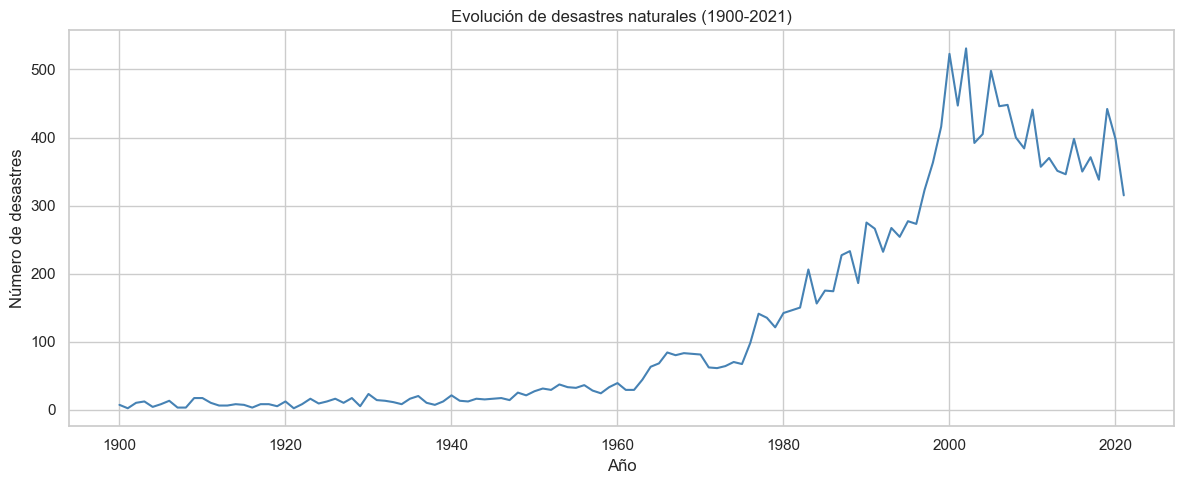

In [34]:
desastres_por_año = df_clean.groupby('year').size().reset_index(name='total')

plt.figure()
sns.lineplot(data=desastres_por_año, x='year', y='total', color='steelblue')
plt.title('Evolución de desastres naturales (1900-2021)')
plt.xlabel('Año')
plt.ylabel('Número de desastres')
plt.tight_layout()
plt.savefig('../images/desastres_por_año.png', dpi=150)
plt.show()

Ahora necesito hacer la gráfica de desastres por continente

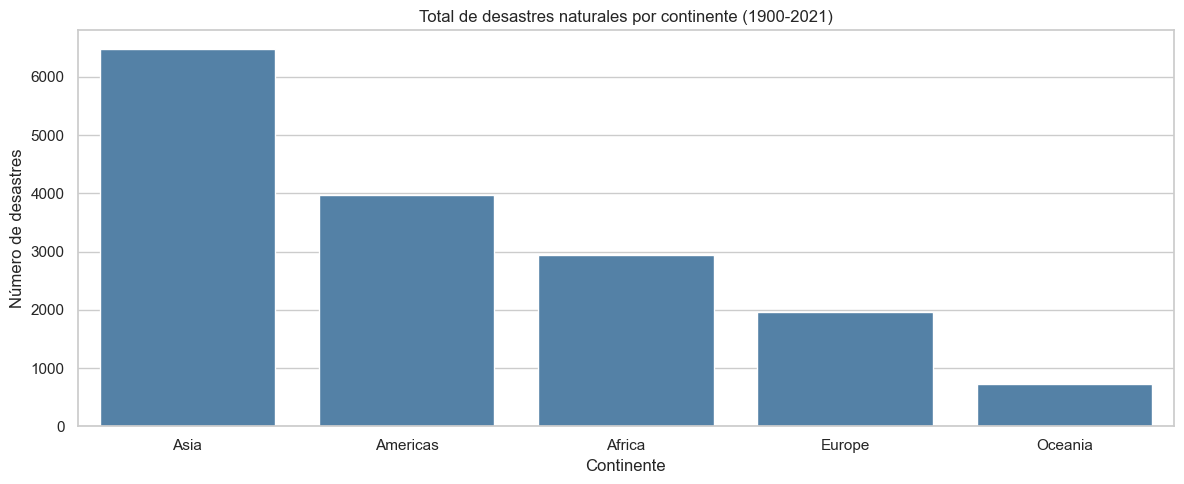

In [35]:
desastres_continente = df_clean.groupby('continent').size().reset_index(name='total').sort_values('total', ascending=False)

plt.figure()
sns.barplot(data=desastres_continente, x='continent', y='total', color='steelblue')
plt.title('Total de desastres naturales por continente (1900-2021)')
plt.xlabel('Continente')
plt.ylabel('Número de desastres')
plt.tight_layout()
plt.savefig('../images/desastres_por_continente.png', dpi=150)
plt.show()

Ahora voy a hacer la de temperaturas

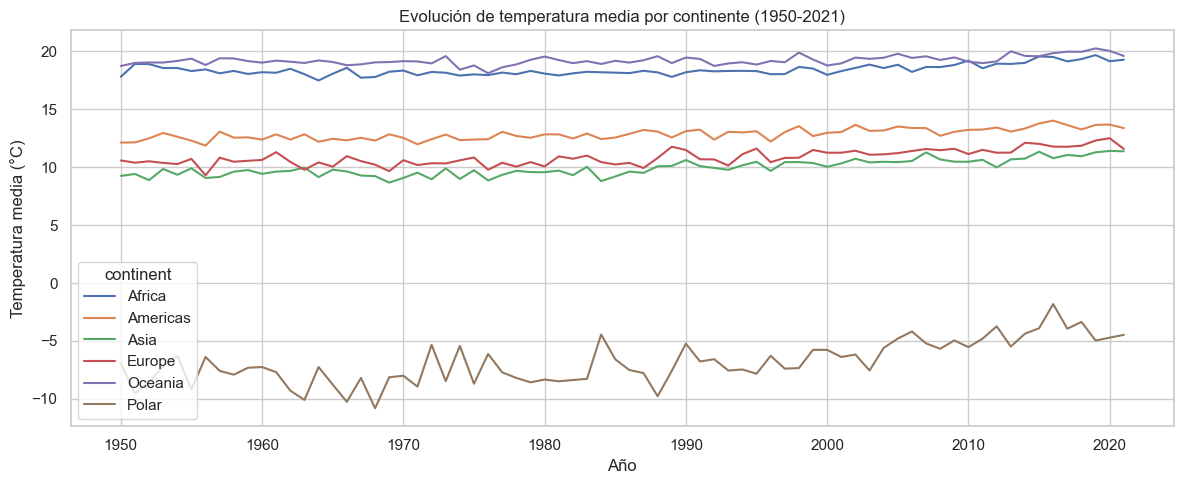

In [36]:
temp_continente = df_temperatures.groupby(['year', 'continent'])['avg_temperature'].mean().reset_index()

plt.figure()
sns.lineplot(data=temp_continente, x='year', y='avg_temperature', hue='continent')
plt.title('Evolución de temperatura media por continente (1950-2021)')
plt.xlabel('Año')
plt.ylabel('Temperatura media (°C)')
plt.tight_layout()
plt.savefig('../images/temperatura_por_continente.png', dpi=150)
plt.show()

Y por último hago, la grafica de cruce de desastres con cruce de temperatura.

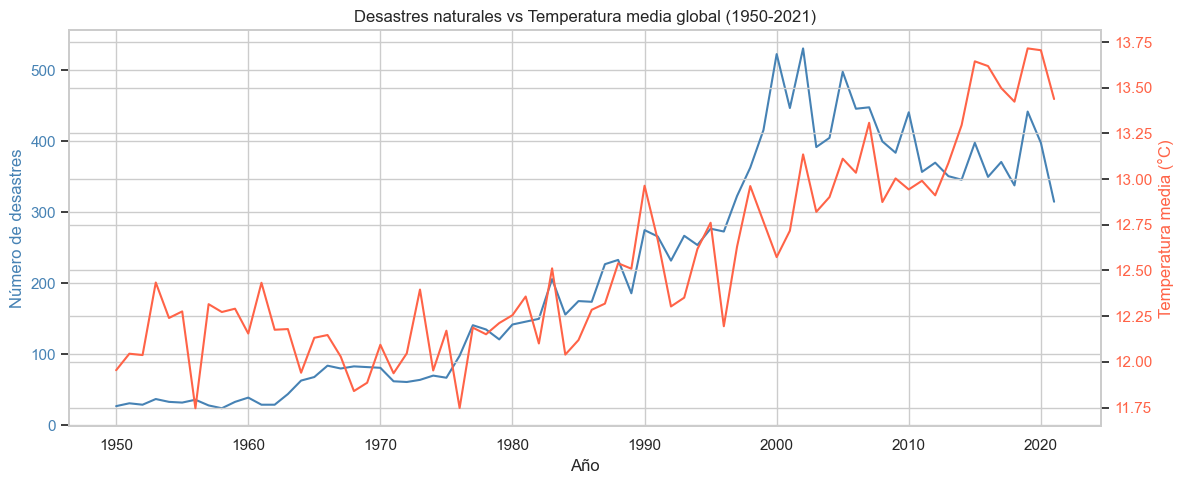

In [38]:
# Agrupamos por año (sin separar por continente)
desastres_año = df_clean[df_clean['year'] >= 1950].groupby('year').size().reset_index(name='total_desastres')
temp_año = df_temperatures.groupby('year')['avg_temperature'].mean().reset_index()

df_cruce = pd.merge(desastres_año, temp_año, on='year')

fig, ax1 = plt.subplots(figsize=(12, 5))

# Desastres - eje izquierdo
color1 = 'steelblue'
ax1.set_xlabel('Año')
ax1.set_ylabel('Número de desastres', color=color1)
ax1.plot(df_cruce['year'], df_cruce['total_desastres'], color=color1, label='Desastres')
ax1.tick_params(axis='y', labelcolor=color1)

# Temperatura - eje derecho
ax2 = ax1.twinx()
color2 = 'tomato'
ax2.set_ylabel('Temperatura media (°C)', color=color2)
ax2.plot(df_cruce['year'], df_cruce['avg_temperature'], color=color2, label='Temperatura')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Desastres naturales vs Temperatura media global (1950-2021)')
fig.tight_layout()
plt.savefig('../images/cruce_desastres_temperatura.png', dpi=150)
plt.show()